In [84]:
import nest_asyncio
nest_asyncio.apply()  # Required for Gremlin driver in Jupyter (avoids "event loop already running" error)

from pathlib import Path
from dotenv import load_dotenv

# Load .env from agents folder
env_path = Path.cwd() / '.env'
if not env_path.exists():
    env_path = Path.cwd() / 'backend' / 'agents' / '.env'
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"✓ Loaded .env from: {env_path}")
else:
    print("⚠ .env not found in agents folder")

✓ Loaded .env from: /Users/rob.bajra/Projects/voice-to-rag/backend/agents/.env


In [85]:
from puppygraph import PuppyGraphClient, PuppyGraphHostConfig
client = PuppyGraphClient(PuppyGraphHostConfig("localhost"))
client.gremlin_query("g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()")


[path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[22cf81a4-ec3b-3c40-85b3-e8095d3e4417]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[e8683443-4966-3966-83a2-2e075e9e8af4]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[e81b35a3-cf72-35e9-97cf-a4be96900eca]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[b49e3ee3-f53d-329b-960c-8baaedfaf5e4]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[95784050-52b8-3f5b-87c6-709556a6eb07]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],


In [86]:

# Databricks model setup (E2 demo workspace)
from openai import OpenAI

ai_client = OpenAI(
  api_key=os.getenv("DATABRICKS_TOKEN"), # your personal access token
  base_url=os.getenv("DATABRICKS_HOST") + "serving-endpoints", # your Databricks workspace instance
)


In [87]:
# PuppyGraph tools (reload to pick up changes)
import importlib
import gremlin_tool
import graph_viz_tool
importlib.reload(gremlin_tool)
importlib.reload(graph_viz_tool)

from gremlin_tool import (
    GENERATE_GREMLIN_TOOL_SPEC, generate_gremlin,
    EXECUTE_GREMLIN_TOOL_SPEC, execute_gremlin,
)
from graph_viz_tool import (
    VISUALIZE_LINEAGE_TOOL_SPEC, visualize_lineage,
)

# Tool specs (dicts for the OpenAI API) and local functions
TOOLS = [GENERATE_GREMLIN_TOOL_SPEC, EXECUTE_GREMLIN_TOOL_SPEC, VISUALIZE_LINEAGE_TOOL_SPEC]



In [88]:
import json

def AGENT(user_query: str):
    # Map tool names to their local Python functions
    TOOL_FUNCTIONS = {
        "generate_gremlin": generate_gremlin,
        "execute_gremlin": execute_gremlin,
        "visualize_lineage": visualize_lineage,
    }

    LLM_ENDPOINT_NAME = "databricks-gemini-3-pro"
    MAX_TOOL_ROUNDS = 5  # safety limit to avoid infinite loops

    messages = [
        {
            "role": "system",
            "content": """
            You are a PuppyGraph agent.
            Use the generate_gremlin tool to convert natural language questions into Gremlin queries.
            Then use the execute_gremlin tool to run the query and return results.
            Always call execute_gremlin after generate_gremlin to get the actual data.
            When the user asks about lineage, data flow, or graph relationships,
            also call visualize_lineage with the same Gremlin query to render an
            inline graph visualization.
            """,
        },
        {
            "role": "user",
            "content": user_query,
        },
    ]

    # Agentic loop: keep calling the LLM until it stops requesting tool calls
    for round_num in range(MAX_TOOL_ROUNDS):
        response = ai_client.chat.completions.create(
            messages=messages,
            model=LLM_ENDPOINT_NAME,
            tools=TOOLS,
            max_tokens=512,
        )

        choice = response.choices[0]

        if choice.finish_reason != "tool_calls":
            # Model is done — print final answer
            print("Final answer:", choice.message.content)
            break

        # Process tool calls
        messages.append(choice.message)

        for tool_call in choice.message.tool_calls:
            fn_name = tool_call.function.name
            fn_args = json.loads(tool_call.function.arguments)
            print(f"[Round {round_num + 1}] Tool call: {fn_name}({fn_args})")

            result = TOOL_FUNCTIONS[fn_name](**fn_args)
            print(f"[Round {round_num + 1}] Tool result: {result}\n")

            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": result,
            })
    else:
        print("⚠ Reached max tool rounds without a final answer")


## Visualize lineage paths as a graph

In [ ]:
# import networkx as nx
# import matplotlib.pyplot as plt

# def paths_to_graph(records):
#     """
#     Convert PuppyGraph/Neo4j path records into a NetworkX directed graph.
    
#     Each record has a "path" key containing a Path with nodes and relationships.
#     Deduplicates nodes/edges automatically via the graph structure.
#     """
#     G = nx.DiGraph()
    
#     for record in records:
#         path = record["path"]
        
#         # Extract nodes from the path
#         for node in path.nodes:
#             node_id = node.element_id
#             label = ",".join(node.labels) if node.labels else "unknown"
#             # Use short name (last segment of the fully-qualified table name)
#             short_name = node_id.split(".")[-1].rstrip("]") if "." in node_id else node_id
#             G.add_node(node_id, label=short_name, full_id=node_id, node_label=label)
        
#         # Extract relationships from the path
#         for rel in path.relationships:
#             start_id = rel.start_node.element_id
#             end_id = rel.end_node.element_id
#             rel_type = rel.type
#             G.add_edge(start_id, end_id, label=rel_type)
    
#     return G


# def draw_lineage_graph(G, figsize=(14, 8)):
#     """Draw a lineage graph with labeled nodes and edges."""
#     plt.figure(figsize=figsize)
    
#     pos = nx.spring_layout(G, k=2.5, seed=42)
    
#     # Draw nodes
#     node_labels = nx.get_node_attributes(G, "label")
#     nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=3000, edgecolors="black", linewidths=1.5)
#     nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_weight="bold")
    
#     # Draw edges with relationship type labels
#     edge_labels = nx.get_edge_attributes(G, "label")
#     nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=25, edge_color="gray", width=2, connectionstyle="arc3,rad=0.1")
#     nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color="red")
    
#     plt.title("Table Lineage Graph", fontsize=14, fontweight="bold")
#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()

In [78]:
AGENT("List 10 tables")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').id().limit(10)"})
[Round 1] Tool result: g.V().hasLabel('table').id().limit(10)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').id().limit(10)"})
[Round 2] Tool result: ["table[00vsdb.agent_analytics.agents_clean]", "table[00vsdb.default.student_silver]", "table[00vsdb.mlops.openai_payload]", "table[03_31_2025_test_cs.dbdemos_aibi_customer_support.agents_bronze]", "table[03_34_2025_test_cs.dbdemos_aibi_cme_marketing_campaign.feedbacks]", "table[04_01_cal_test_aibi_customer_support.dbdemos_aibi_customer_support.agents_bronze]", "table[04_29_2025_test_cal_claims.dbdemos_fsi_smart_claims.__materialization_mat_624bbb00_aa4d_499b_b4d9_e0313e828d3d_claim_policy_telematics_1]", "table[04_29_2025_test_cal_claims.dbdemos_fsi_smart_claims.claim_policy_telematics]", "table[04_29_2025_test_cal_claims.dbdemos_fsi_smart_claims.damage_predictions]", "table[04_29_2025_test_cal_claims.dbdem

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()"})
[Round 1] Tool result: g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()"})
[Round 2] Tool result: ["path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[22cf81a4-ec3b-3c40-85b3-e8095d3e4417]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]]", "path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[e8683443-4966-3966-83a2-2e075e9e8af4]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]]", "path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[e81b35a3-cf72-35e9-97cf-a4be96900eca]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]]", "path[v[

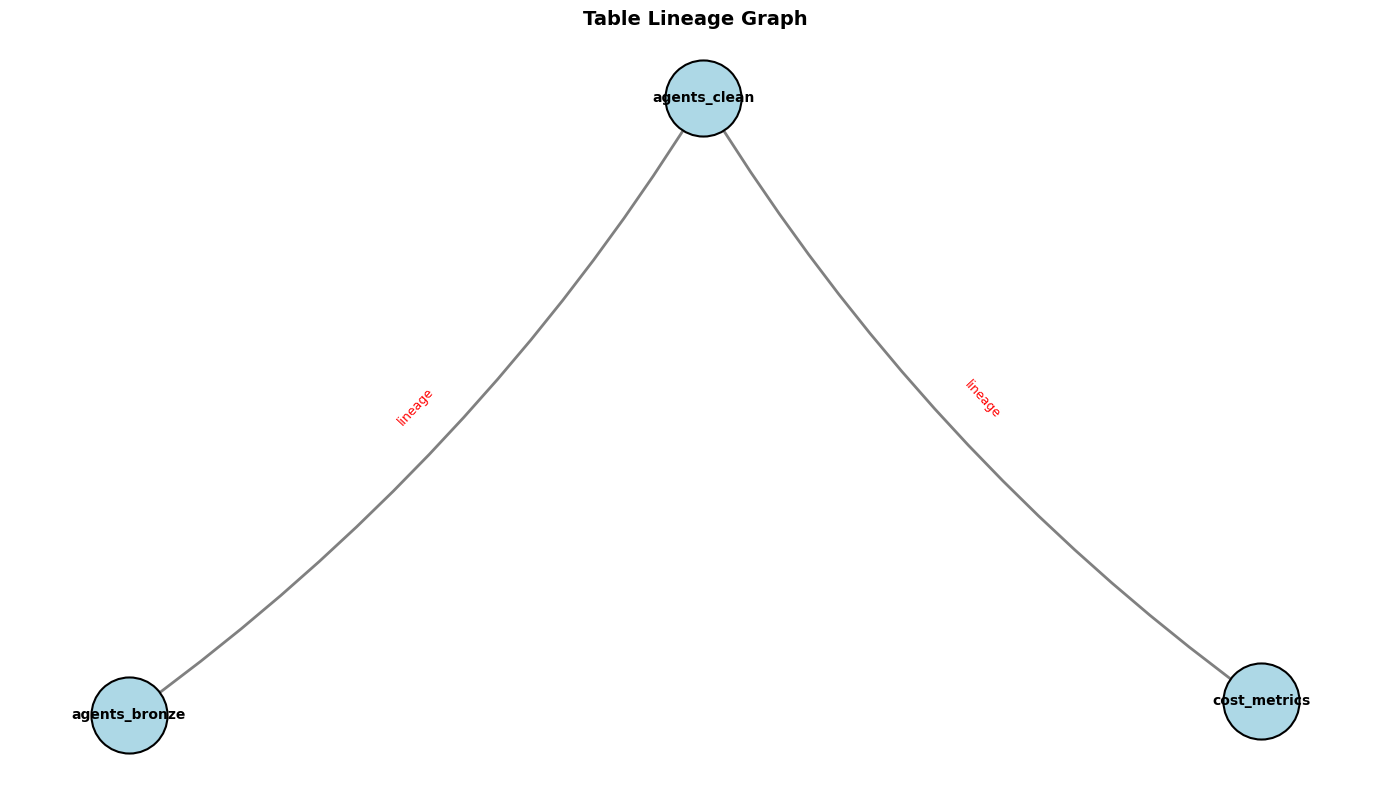

[Round 2] Tool result: Lineage graph rendered: 3 nodes (agents_clean, cost_metrics, agents_bronze), 2 edges.

Final answer: The lineage for table `00vsdb.agent_analytics.agents_clean` shows the following relationships:

**Upstream (Source):**
*   `00vsdb.agent_analytics.agents_bronze` flows into `00vsdb.agent_analytics.agents_clean`.

**Downstream (Target):**
*   `00vsdb.agent_analytics.agents_clean` flows into `00vsdb.agent_analytics.cost_metrics`.


In [79]:
AGENT("show lineage of 00vsdb.agent_analytics.agents_clean")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().id().dedup().count()"})
[Round 1] Tool result: g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().id().dedup().count()

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().id().dedup().count()"})
[Round 2] Tool result: [3]

[Round 3] Tool call: visualize_lineage({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().path()"})


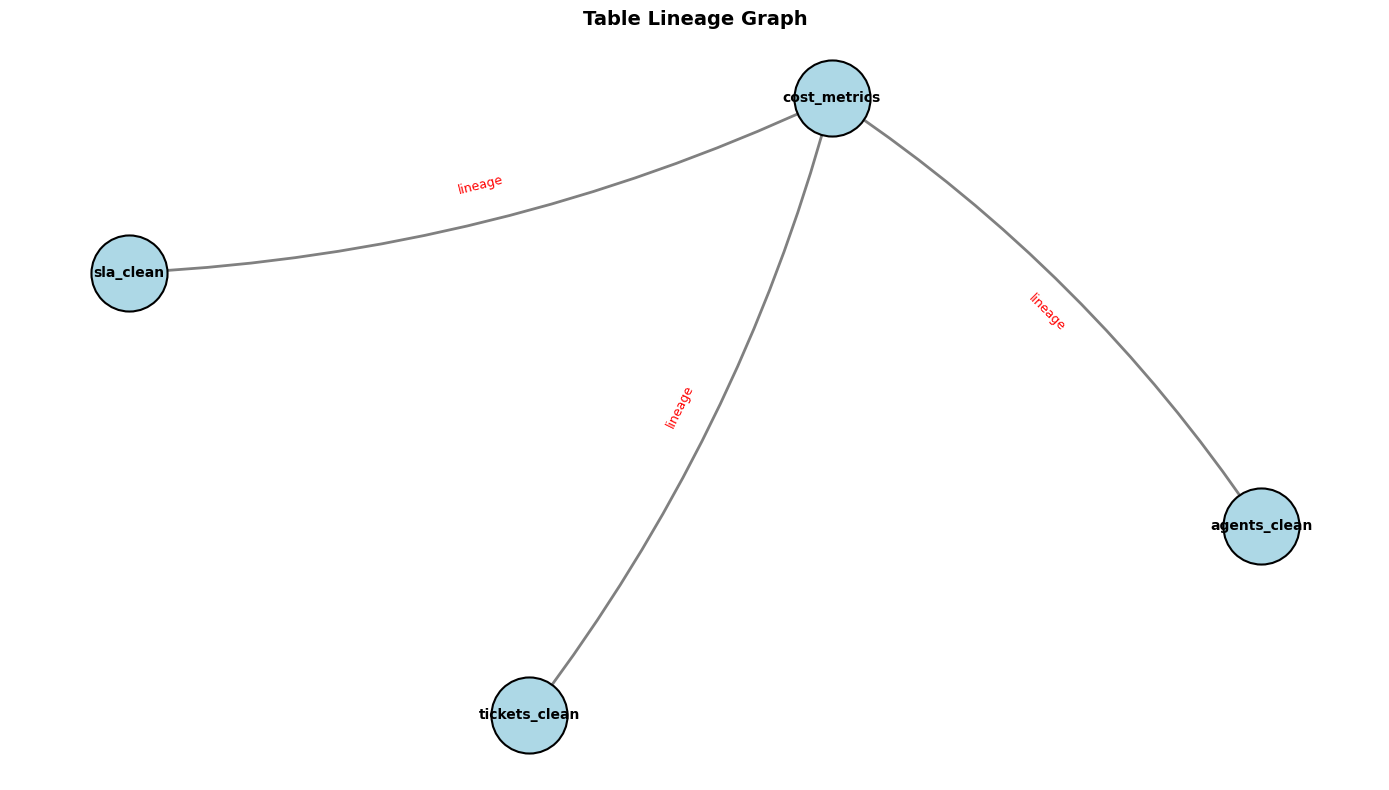

[Round 3] Tool result: Lineage graph rendered: 4 nodes (cost_metrics, agents_clean, tickets_clean, sla_clean), 3 edges.

Final answer: There are **3** unique tables upstream of `00vsdb.agent_analytics.cost_metrics`.

I have also generated a lineage visualization showing the `cost_metrics` table and its 3 upstream sources.


In [82]:
AGENT("How many unique tables are upsteam of 00vsdb.agent_analytics.cost_metrics")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().path().limit(20)"})
[Round 1] Tool result: g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().path().limit(20)

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().path().limit(20)"})
[Round 2] Tool result: ["path[v[table[00vsdb.agent_analytics.cost_metrics]], e[lineage[abfc459f-a928-3e69-9fa7-e94ec4077c91]][table[00vsdb.agent_analytics.sla_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]], v[table[00vsdb.agent_analytics.sla_clean]]]", "path[v[table[00vsdb.agent_analytics.cost_metrics]], e[lineage[264f2529-df28-3d25-863e-268d08dd86c1]][table[00vsdb.agent_analytics.sla_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]], v[table[00vsdb.agent_analytics.sla_clean]]]", "path[v[table[00vsdb.agent_analytics.cost_metrics]], e[lineage[e8d0bd10-7a83-309e-

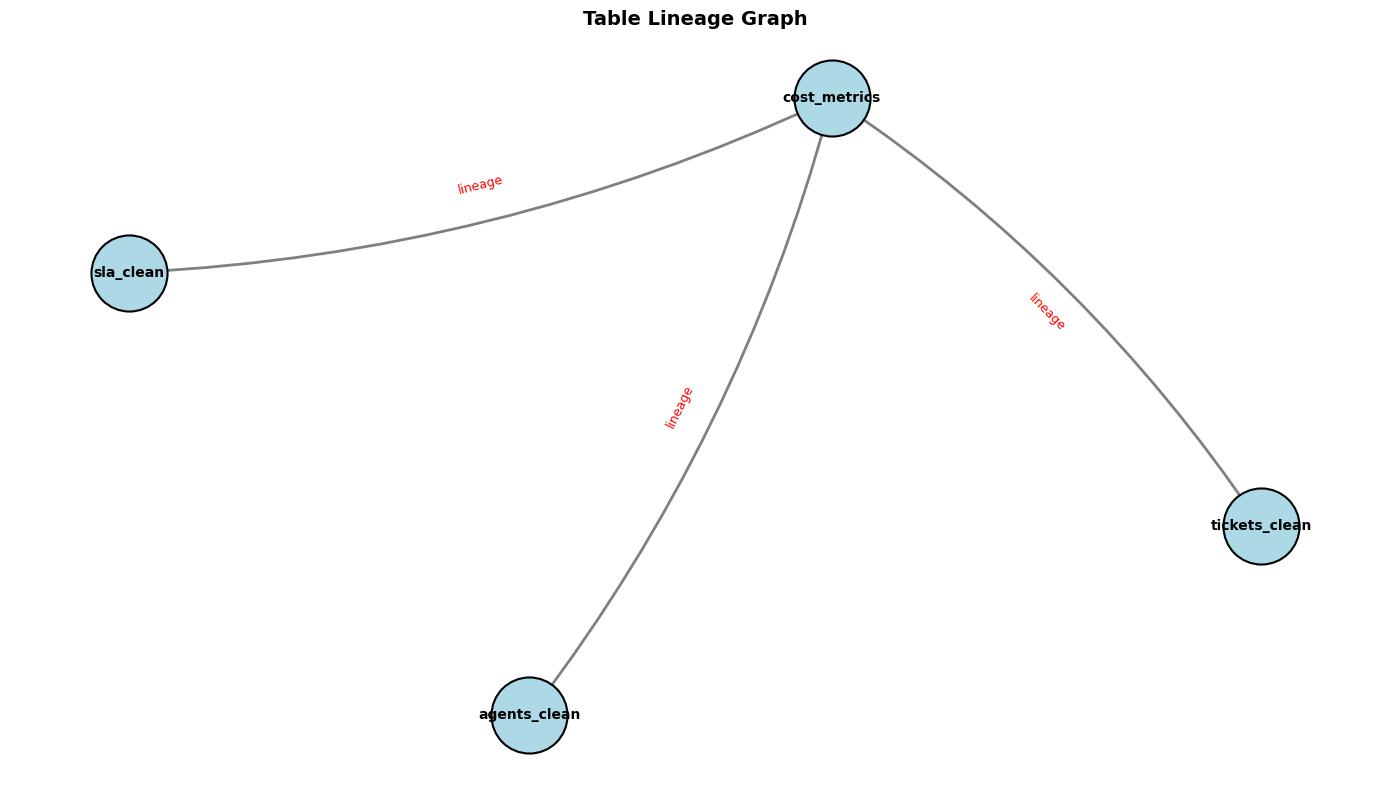

[Round 2] Tool result: Lineage graph rendered: 4 nodes (cost_metrics, tickets_clean, agents_clean, sla_clean), 3 edges.

Final answer: The upstream lineage for `00vsdb.agent_analytics.cost_metrics` includes the following tables:

*   `00vsdb.agent_analytics.sla_clean`
*   `00vsdb.agent_analytics.tickets_clean`
*   `00vsdb.agent_analytics.agents_clean`

These tables feed data into `cost_metrics`. I have generated a lineage graph visualization for you.


In [81]:
AGENT("Show upstream lineage of 00vsdb.agent_analytics.cost_metrics")

In [83]:
AGENT("What is the most connected table")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').order().by(bothE('lineage').count(), desc).limit(1).id()"})
[Round 1] Tool result: g.V().hasLabel('table').order().by(bothE('lineage').count(), desc).limit(1).id()

[Round 2] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').order().by(bothE('lineage').count(), desc).limit(1).id()"})
[Round 2] Tool result: {"error": "Operation timed out after 30000 ms!"}

[Round 3] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'degree').by(id()).by(bothE('lineage').count()).order().by(select('degree'), desc).limit(1)"})
[Round 3] Tool result: g.V().hasLabel('table').project('id', 'degree').by(id()).by(bothE('lineage').count()).order().by(select('degree'), desc).limit(1)

[Round 4] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'degree').by(id()).by(bothE('lineage').count()).order().by(select('degree'), desc).limit(1)"})
[Round 4


Received error message '{'requestId': '10619645-bb95-425b-98b7-355671bf3014', 'status': {'code': 598, 'message': "Evaluation exceeded the configured 'evaluationTimeout' threshold of 300000 ms or evaluation was otherwise cancelled directly for request [g.V().hasLabel('table').order().by(bothE('lineage').count(), desc).limit(1).id()]", 'attributes': {'stackTrace': "java.util.concurrent.TimeoutException: Evaluation exceeded the configured 'evaluationTimeout' threshold of 300000 ms or evaluation was otherwise cancelled directly for request [g.V().hasLabel('table').order().by(bothE('lineage').count(), desc).limit(1).id()]\n\tat org.apache.tinkerpop.gremlin.groovy.engine.GremlinExecutor.lambda$eval$1(GremlinExecutor.java:375)\n\tat io.netty.util.concurrent.PromiseTask.runTask(PromiseTask.java:98)\n\tat io.netty.util.concurrent.ScheduledFutureTask.run(ScheduledFutureTask.java:160)\n\tat io.netty.util.concurrent.AbstractEventExecutor.runTask(AbstractEventExecutor.java:173)\n\tat io.netty.util